# Détection d'intrusion NSL-KDD — DBN (RBM empilées) + ELM (Liu et al., 2016) — binaire, version améliorée

Classification binaire **Normal vs Attaque**, même architecture que la version précédente (RBM empilées → ELM), avec **3 améliorations ciblées**


In [ ]:
import warnings
warnings.filterwarnings("ignore")
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score,
                              precision_score, f1_score, classification_report, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
%matplotlib inline

## 1. Chargement des données (fichiers uploadés manuellement)

In [ ]:
# Optionnel : décommente pour uploader directement depuis cette cellule
# from google.colab import files
# uploaded = files.upload()

training_set_path = "KDDTrain+.txt"
test_set_path = "KDDTest+.txt"

training_df = pd.read_csv(training_set_path, header=None)
testing_df = pd.read_csv(test_set_path, header=None)

print("Training set :", training_df.shape)
print("Testing set  :", testing_df.shape)

Training set : (125973, 43)
Testing set  : (22544, 43)


In [ ]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'outcome','difficulty'
]
training_df.columns = columns
testing_df.columns = columns
training_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 2. Étiquetage binaire : Normal vs Attaque

In [ ]:
dos_attacks=["snmpgetattack","back","land","neptune","smurf","teardrop","pod","apache2","udpstorm","processtable","mailbomb"]
r2l_attacks=["snmpguess","worm","httptunnel","named","xlock","xsnoop","sendmail","ftp_write","guess_passwd","imap","multihop","phf","spy","warezclient","warezmaster"]
u2r_attacks=["sqlattack","buffer_overflow","loadmodule","perl","rootkit","xterm","ps"]
probe_attacks=["ipsweep","nmap","portsweep","satan","saint","mscan"]
attack_types = set(dos_attacks) | set(r2l_attacks) | set(u2r_attacks) | set(probe_attacks)

classes = ["Normal", "Attack"]

def label_attack(row):
    return classes[1] if row["outcome"] in attack_types else classes[0]

if "Class" not in training_df.columns:
    test_samples_length = len(testing_df)
    df = pd.concat([training_df, testing_df])
    df["Class"] = df.apply(label_attack, axis=1)
    df = df.drop("outcome", axis=1)
    df = df.drop("difficulty", axis=1)

    training_df = df.iloc[:-test_samples_length, :].copy()
    testing_df = df.iloc[-test_samples_length:, :].copy()
else:
    print("Déjà étiqueté (colonne 'Class' présente) — cellule ignorée pour éviter un double passage.")

print(training_df["Class"].value_counts())
print()
print(testing_df["Class"].value_counts())

Class
Normal    67343
Attack    58630
Name: count, dtype: int64

Class
Attack    12833
Normal     9711
Name: count, dtype: int64


## 3. Prétraitement : one-hot encoding + normalisation (41 → ~122 features)

In [ ]:
def minmax_scale_values(training_df, testing_df, col_name):
    scaler = MinMaxScaler()
    scaler = scaler.fit(training_df[col_name].values.reshape(-1, 1))
    training_df[col_name] = scaler.transform(training_df[col_name].values.reshape(-1, 1))
    testing_df[col_name] = scaler.transform(testing_df[col_name].values.reshape(-1, 1))

def encode_text(training_df, testing_df, name):
    training_set_dummies = pd.get_dummies(training_df[name])
    testing_set_dummies = pd.get_dummies(testing_df[name])
    for x in training_set_dummies.columns:
        dummy_name = "{}_{}".format(name, x)
        training_df[dummy_name] = training_set_dummies[x]
        if x in testing_set_dummies.columns:
            testing_df[dummy_name] = testing_set_dummies[x]
        else:
            testing_df[dummy_name] = np.zeros(len(testing_df))
    training_df.drop(name, axis=1, inplace=True)
    testing_df.drop(name, axis=1, inplace=True)

symbolic_columns = ["protocol_type", "service", "flag"]
label_column = "Class"
for column in df.columns:
    if column in symbolic_columns:
        encode_text(training_df, testing_df, column)
    elif column != label_column:
        minmax_scale_values(training_df, testing_df, column)

print("Nombre de features après encodage :", training_df.shape[1] - 1)
training_df.head()

Nombre de features après encodage : 122


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0.0,3.558064e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,0.0,1.057999e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
3,0.0,1.681203e-07,6.223962e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,0.0,1.442067e-07,3.206260e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
X_train = training_df.drop("Class", axis=1).values.astype("float32")
y_train_labels = training_df["Class"].values
X_test = testing_df.drop("Class", axis=1).values.astype("float32")
y_test_labels = testing_df["Class"].values

class_to_idx = {c: i for i, c in enumerate(classes)}
y_train_idx = np.array([class_to_idx[c] for c in y_train_labels])
y_test_idx = np.array([class_to_idx[c] for c in y_test_labels])

y_train = to_categorical(y_train_idx, num_classes=len(classes))
y_test = to_categorical(y_test_idx, num_classes=len(classes))

X_train = np.clip(X_train, 0.0, 1.0)
X_test = np.clip(X_test, 0.0, 1.0)

print("X_train :", X_train.shape, " y_train :", y_train.shape)
print("X_test  :", X_test.shape,  " y_test  :", y_test.shape)

X_train : (125973, 122)  y_train : (125973, 2)
X_test  : (22544, 122)  y_test  : (22544, 2)


## 4. RBM (Restricted Boltzmann Machine) — brique de base du DBN

Une RBM est composée d'une couche visible et d'une couche cachée, toutes deux binaires stochastiques, sans connexion intra-couche. Elle est entraînée à reconstruire son entrée par **Contrastive Divergence (CD-1)**.

In [ ]:
class RBM:
    def __init__(self, n_visible, n_hidden, seed=42):
        rng = np.random.RandomState(seed)
        self.W = rng.normal(0, 0.01, size=(n_visible, n_hidden)).astype(np.float32)
        self.b_hidden = np.zeros(n_hidden, dtype=np.float32)
        self.b_visible = np.zeros(n_visible, dtype=np.float32)

    @staticmethod
    def _sigmoid(x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

    def prob_hidden(self, v):
        return self._sigmoid(v @ self.W + self.b_hidden)

    def prob_visible(self, h):
        return self._sigmoid(h @ self.W.T + self.b_visible)

    def sample_hidden(self, v):
        p_h = self.prob_hidden(v)
        h = (np.random.rand(*p_h.shape) < p_h).astype(np.float32)
        return p_h, h

    def sample_visible(self, h):
        p_v = self.prob_visible(h)
        v = (np.random.rand(*p_v.shape) < p_v).astype(np.float32)
        return p_v, v

    def train(self, X, epochs=15, batch_size=128, lr=0.05, verbose=True):
        n = X.shape[0]
        for epoch in range(epochs):
            perm = np.random.permutation(n)
            X_shuffled = X[perm]
            recon_error = 0.0
            for start in range(0, n, batch_size):
                v0 = X_shuffled[start:start + batch_size]
                p_h0, h0 = self.sample_hidden(v0)
                p_v1, v1 = self.sample_visible(h0)
                p_h1, _ = self.sample_hidden(p_v1)
                batch_n = v0.shape[0]
                positive_grad = v0.T @ p_h0
                negative_grad = p_v1.T @ p_h1
                self.W += lr * (positive_grad - negative_grad) / batch_n
                self.b_visible += lr * np.mean(v0 - p_v1, axis=0)
                self.b_hidden += lr * np.mean(p_h0 - p_h1, axis=0)
                recon_error += np.sum((v0 - p_v1) ** 2)
            if verbose:
                print(f"  Epoch {epoch + 1}/{epochs} - erreur de reconstruction : {recon_error / n:.4f}")

    def transform(self, X):
        return self.prob_hidden(X)

## 5. Empilement glouton des RBM → DBN

Architecture : `input_dim → 100 → 60 → 30`.

In [ ]:
hidden_sizes = [100, 60, 30]
rbm_epochs = 15
rbm_batch_size = 128
rbm_lr = 0.05

rbms = []
current_train = X_train.copy()
for i, h_size in enumerate(hidden_sizes):
    v_size = current_train.shape[1]
    print(f"--- Entraînement RBM {i + 1}/{len(hidden_sizes)} : {v_size} -> {h_size} ---")
    rbm = RBM(v_size, h_size, seed=42 + i)
    rbm.train(current_train, epochs=rbm_epochs, batch_size=rbm_batch_size, lr=rbm_lr)
    rbms.append(rbm)
    current_train = rbm.transform(current_train)

print("Pré-entraînement du DBN terminé.")

--- Entraînement RBM 1/3 : 122 -> 100 ---
  Epoch 1/15 - erreur de reconstruction : 2.3376
  Epoch 2/15 - erreur de reconstruction : 1.2113
  Epoch 3/15 - erreur de reconstruction : 0.9757
  Epoch 4/15 - erreur de reconstruction : 0.8526
  Epoch 5/15 - erreur de reconstruction : 0.7521
  Epoch 6/15 - erreur de reconstruction : 0.6895
  Epoch 7/15 - erreur de reconstruction : 0.6512
  Epoch 8/15 - erreur de reconstruction : 0.6234
  Epoch 9/15 - erreur de reconstruction : 0.6006
  Epoch 10/15 - erreur de reconstruction : 0.5816
  Epoch 11/15 - erreur de reconstruction : 0.5664
  Epoch 12/15 - erreur de reconstruction : 0.5505
  Epoch 13/15 - erreur de reconstruction : 0.5380
  Epoch 14/15 - erreur de reconstruction : 0.5271
  Epoch 15/15 - erreur de reconstruction : 0.5170
--- Entraînement RBM 2/3 : 100 -> 60 ---
  Epoch 1/15 - erreur de reconstruction : 3.0154
  Epoch 2/15 - erreur de reconstruction : 1.0160
  Epoch 3/15 - erreur de reconstruction : 0.8080
  Epoch 4/15 - erreur de reco

In [ ]:
def dbn_transform(X, rbms):
    out = X
    for rbm in rbms:
        out = rbm.transform(out)
    return out

X_train_dbn = dbn_transform(X_train, rbms)
X_test_dbn = dbn_transform(X_test, rbms)

print("X_train_dbn :", X_train_dbn.shape)
print("X_test_dbn  :", X_test_dbn.shape)

X_train_dbn : (125973, 30)
X_test_dbn  : (22544, 30)


## 6. Standardisation des features du DBN (correction n°1)

Les sorties des RBM sont des probabilités sigmoïdes, souvent proches de 0 ou 1 après plusieurs couches. Projetées telles quelles dans l'ELM (poids aléatoires), elles saturent encore plus la sigmoïde de l'ELM et font perdre du signal utile. On standardise (z-score, calculé sur le train uniquement) pour redonner de la dynamique au signal avant l'ELM.

In [ ]:
dbn_scaler = StandardScaler()
X_train_dbn_std = dbn_scaler.fit_transform(X_train_dbn)
X_test_dbn_std = dbn_scaler.transform(X_test_dbn)

## 7. ELM (Extreme Learning Machine)

Couche cachée à poids **aléatoires et fixes**, poids de sortie appris par moindres carrés pondérés par classe :

$$\beta = (H^T D H + \lambda I)^{-1} H^T D T$$

In [ ]:
class ELM:
    def __init__(self, n_input, n_hidden, n_output, activation='sigmoid', seed=42):
        rng = np.random.RandomState(seed)
        self.W_in = rng.normal(0, 1, size=(n_input, n_hidden)).astype(np.float32)
        self.b_in = rng.normal(0, 1, size=(n_hidden,)).astype(np.float32)
        self.activation = activation
        self.beta = None

    def _activate(self, X):
        Z = X @ self.W_in + self.b_in
        if self.activation == 'sigmoid':
            return 1.0 / (1.0 + np.exp(-np.clip(Z, -30, 30)))
        elif self.activation == 'tanh':
            return np.tanh(Z)
        else:
            raise ValueError("activation inconnue")

    def fit(self, X, T, sample_weight=None, reg=1.0):
        H = self._activate(X)
        n_hidden = H.shape[1]
        if sample_weight is not None:
            Hw = H * sample_weight[:, None]
            A = H.T @ Hw + reg * np.eye(n_hidden)
            b = Hw.T @ T
        else:
            A = H.T @ H + reg * np.eye(n_hidden)
            b = H.T @ T
        self.beta = np.linalg.solve(A, b)

    def predict_scores(self, X):
        H = self._activate(X)
        return H @ self.beta

    def predict(self, X):
        return np.argmax(self.predict_scores(X), axis=1)

In [ ]:
raw_weights = compute_class_weight('balanced', classes=np.unique(y_train_idx), y=y_train_idx)
MAX_WEIGHT = 20.0
class_weights = np.minimum(raw_weights, MAX_WEIGHT)
for c, w_raw, w_used in zip(classes, raw_weights, class_weights):
    print(f"{c:8s} -> poids brut {w_raw:8.2f}  -> poids utilisé {w_used:.2f}")

Normal   -> poids brut     0.94  -> poids utilisé 0.94
Attack   -> poids brut     1.07  -> poids utilisé 1.07


## 8. Split stratifié (fit / validation) — correction n°2

On garde 15% du train de côté, de façon stratifiée, uniquement pour **choisir le seuil de décision et vérifier les hyperparamètres**. Le jeu de test (`KDDTest+`) n'est jamais touché pendant ce réglage.

In [ ]:
idx_fit, idx_val = train_test_split(
    np.arange(len(y_train_idx)), test_size=0.15, stratify=y_train_idx, random_state=42
)

X_fit, y_fit_idx = X_train_dbn_std[idx_fit], y_train_idx[idx_fit]
X_val, y_val_idx = X_train_dbn_std[idx_val], y_train_idx[idx_val]

y_fit = to_categorical(y_fit_idx, num_classes=len(classes))
sw_fit = class_weights[y_fit_idx].astype(np.float32)

print("Fit :", X_fit.shape, " Validation :", X_val.shape)

Fit : (107077, 30)  Validation : (18896, 30)


## 9. Entraînement ELM sur le fit-set + réglage du seuil (correction n°2)

On entraîne l'ELM sur 85% du train, on calcule ses scores continus sur les 15% de validation, puis on choisit le seuil de décision qui maximise **DR − FPR** (critère de Youden) sur la classe `Attack` — plutôt que de garder l'argmax par défaut (seuil implicite à 0).

In [ ]:
n_hidden_elm = 500
reg_elm = 1.0

elm_val = ELM(n_input=X_fit.shape[1], n_hidden=n_hidden_elm, n_output=len(classes),
              activation='sigmoid', seed=42)
elm_val.fit(X_fit, y_fit, sample_weight=sw_fit, reg=reg_elm)

val_scores = elm_val.predict_scores(X_val)
val_margin = val_scores[:, 1] - val_scores[:, 0]  # score Attack - score Normal

fpr_curve, tpr_curve, thresholds = roc_curve(y_val_idx, val_margin)
youden_j = tpr_curve - fpr_curve
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print(f"Seuil choisi (argmax classique = 0.0) : {best_threshold:.4f}")
print(f"Sur la validation à ce seuil -> DR(Attack) = {tpr_curve[best_idx]:.4f}, FPR(Attack) = {fpr_curve[best_idx]:.4f}")

from sklearn.metrics import roc_auc_score
print(f"AUC (validation) : {roc_auc_score(y_val_idx, val_margin):.4f}")

Seuil choisi (argmax classique = 0.0) : 0.1816
Sur la validation à ce seuil -> DR(Attack) = 0.9685, FPR(Attack) = 0.0056
AUC (validation) : 0.9978


## 10. Modèle final : ré-entraînement sur 100% du train (correction n°3)

Le seuil est choisi, on ré-entraîne maintenant l'ELM sur **l'intégralité** du train (fit + validation) avec les mêmes hyperparamètres, pour ne perdre aucune donnée d'entraînement dans le modèle final. Le seuil trouvé à l'étape précédente reste valable (il a été choisi sur des données jamais vues par l'ELM final).

In [ ]:
sample_weights_full = class_weights[y_train_idx].astype(np.float32)

elm = ELM(n_input=X_train_dbn_std.shape[1], n_hidden=n_hidden_elm, n_output=len(classes),
          activation='sigmoid', seed=42)
elm.fit(X_train_dbn_std, y_train, sample_weight=sample_weights_full, reg=reg_elm)
print("ELM final entraîné sur 100% du train.")

ELM final entraîné sur 100% du train.


## 11. Évaluation sur le jeu de test avec le seuil ajusté

- **DR (Detection Rate)** = recall de `Attack`.
- **FPR (False Positive Rate)** = proportion de `Normal` classé à tort `Attack`.

In [ ]:
test_scores = elm.predict_scores(X_test_dbn_std)
test_margin = test_scores[:, 1] - test_scores[:, 0]
y_pred = (test_margin > best_threshold).astype(int)
y_true = y_test_idx

accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("Accuracy globale : {:.4f}".format(accuracy))
print("Precision (macro) : {:.4f}".format(precision_macro))
print("Recall (macro)    : {:.4f}".format(recall_macro))
print("F1 (macro)        : {:.4f}\n".format(f1_macro))

print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

Accuracy globale : 0.7657
Precision (macro) : 0.7932
Recall (macro)    : 0.7857
F1 (macro)        : 0.7654

              precision    recall  f1-score   support

      Normal       0.66      0.93      0.77      9711
      Attack       0.92      0.64      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.79      0.79      0.77     22544
weighted avg       0.81      0.77      0.76     22544



In [ ]:
n = len(y_true)
print(f"{'Classe':8s}  {'ACC':>8s}  {'DR':>8s}  {'FPR':>8s}")
for i, class_ in enumerate(classes):
    is_class = (y_true == i)
    pred_class = (y_pred == i)

    tp = np.sum(is_class & pred_class)
    fn = np.sum(is_class & ~pred_class)
    fp = np.sum(~is_class & pred_class)
    tn = np.sum(~is_class & ~pred_class)

    acc_c = (tp + tn) / n
    dr = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    fpr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')

    print(f"{class_:8s}  {acc_c:8.4f}  {dr:8.4f}  {fpr:8.4f}")

Classe         ACC        DR       FPR
Normal      0.7657    0.9306    0.3592
Attack      0.7657    0.6408    0.0694


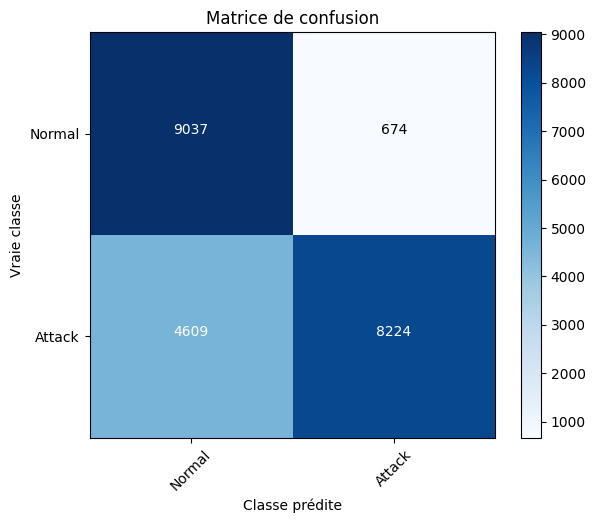

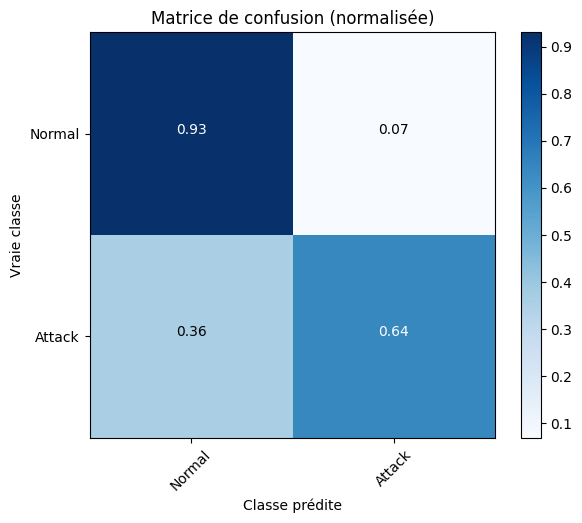

In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Matrice de confusion', cmap=plt.cm.Blues):
    plt.figure(figsize=(6, 5))
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('Vraie classe')
    plt.xlabel('Classe prédite')
    plt.show()

cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, classes)
plot_confusion_matrix(cm, classes, normalize=True, title='Matrice de confusion (normalisée)')

## 12. Pistes si ça ne suffit pas encore

- **Le seuil est un curseur DR/FPR, pas une baguette magique** : si tu veux un DR encore plus haut quitte à accepter plus de fausses alertes, choisis le seuil qui donne `FPR ≈ 0.10` ou `0.15` sur la validation (regarde `fpr_curve`/`tpr_curve`/`thresholds` au lieu du seuil de Youden) plutôt que le compromis "équilibré" par défaut.
- **`reg_elm`** : essaie 0.1 et 0.01, maintenant que les features sont standardisées ça peut changer l'optimum trouvé précédemment (avec reg=1.0 sur des features saturées).
- **`n_hidden_elm`** : essaie 1000-2000 maintenant que le signal d'entrée est mieux réparti — plus de capacité peut mieux exploiter les features non saturées.
- **`hidden_sizes` du DBN** : essaie de compresser moins fort, ex. `[100, 60]` (2 RBM au lieu de 3) pour perdre moins d'information avant l'ELM.
- Si le FPR(Attack) remonte trop avec le nouveau seuil, c'est le signe que le compromis penche maintenant trop vers la détection — resserre le seuil vers une valeur plus proche de celle de Youden.